In [1]:
# 라이브러리 임포트
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

import cv2 # 카메라 영상 전처리용
import warnings
warnings.filterwarnings('ignore')

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)


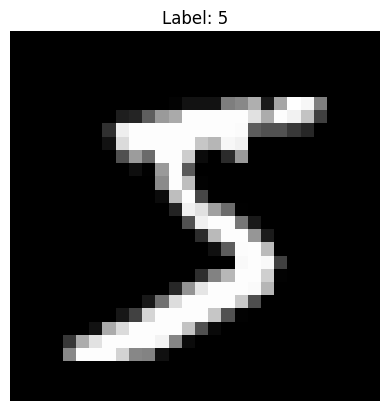

In [2]:
# MNIST 데이터 셋 불러오기 / test
from tensorflow.keras.datasets import mnist

# 1) 데이터 불러오기
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2) 데이터 크기 확인 
print("x_train shape:", x_train.shape) #(60000장 28x28 배열)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)

# 3) 이미지 test
plt.imshow(x_train[0], cmap = 'gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [ ]:
# 1) 정규화 : 픽셀값(0~255) > 0~1(CNN용) 사이로 변환
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 2) CNN 입력 형태로 차원 확장 (28,28) > (28,28,1)
x_train = np.expand_dims(x_train, axis = -1)
x_test = np.expand_dims(x_test, axis = -1)

print("After reshape:")
print("x_train shape:", x_train.shape) #(60000, 28, 28, 1)
print("x_trian shape:", x_test.shape)

# 3) 원 핫 인코딩 > CNN 학습 방식
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("y_train shape:", y_train.shape) # (60000, 10)

After reshape:
x_train shape: (60000, 28, 28, 1)
x_trian shape: (10000, 28, 28, 1)
y_train shape: (60000, 10)


In [8]:
# CNN 모델 구성
model = models.Sequential([

    # 1) 첫 번째 Convolution 블록
    # Conv2D(32, (3,3)) : 3x3 필터 32개 > 숫자의 특징(모서리, 굴곡, 패턴) 추출
    # relu : 음수 제거 > 학습 효율 증가
    # MaxPooling : 노이즈 제거 > 중요 특징만 남김
    layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28, 28, 1)),
    layers.MaxPooling2D((2,2)),

    # 2) 두 번째 Convolution 블록
    # 더 세부적인 특징(곡선, 패턴) 학습
    # 첫번째 Conv : 선/모서리
    # 두번째 Conv : 형태
    # 세번째 Conv : 자세한 패턴
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),

    # 3) 세 번째 Convolution 레이어
    layers.Conv2D(64, (3,3), activation = 'relu'),

    # 4) Dense 레이어를 위한 Flatten
    # Conv 레이어는 2D(이미지 형태)
    # Dense 레이어는 1D(일렬) 데이터만 받음
    # Flatten : 이미지 픽셀(2D) > 일렬(1D)
    layers.Flatten(),

    # 5) Fully-connected (Dense)
    # CNN이 학습한 특징을 조합해 어떤 숫자인지 분석
    # Dense(10, softmax): 0~9에 대한 숫자 확률 10개 출력
    # softmax > 전체 합 1 > 가장 큰 확률의 인덱스가 예측 숫자
    layers.Dense(64, activation = 'relu'),
    layers.Dense(10, activation = 'softmax') # 숫자 0~9 확률 출력
])

# 모델 구조 요약 출력
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# 1) 모델 컴파일
# loss : 정답확률 1인 곳과 예측 확률이 얼마나 차이나는지 계산
# metrics 학습 중 정확도(% 맞춘 비율)를 보여줌
model.compile(
    optimizer = 'adam',
    loss = 'categorical_crossentropy', 
    metrics = ['accuracy']
)

# 2) 모델 학습
history = model.fit(
    x_train, y_train,
    epochs = 20, # 반복 학습 횟수
    batch_size = 64, # 64장씩 묶어서 학습
    validation_split = 0.1, # 오버피팅 체크
    verbose = 1
)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9410 - loss: 0.1899 - val_accuracy: 0.9870 - val_loss: 0.0485
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9838 - loss: 0.0515 - val_accuracy: 0.9885 - val_loss: 0.0411
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9885 - loss: 0.0367 - val_accuracy: 0.9883 - val_loss: 0.0391
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9909 - loss: 0.0290 - val_accuracy: 0.9872 - val_loss: 0.0395
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9931 - loss: 0.0232 - val_accuracy: 0.9915 - val_loss: 0.0309
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9945 - loss: 0.0175 - val_accuracy: 0.9920 - val_loss: 0.0308
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9948 - loss: 0.0158 - val_accuracy: 0.9917 - val_loss: 0.0335
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9958 - loss: 0.0128 - val_accuracy: 0.

In [11]:
# 모델 저장
model.save('mnist_cnn.h5')

print("모델 저장 완료 : mnist_cnn.h5")

모델 저장 완료 : mnist_cnn.h5
